# Global Superstore Sales Performance Dashboard

### Interactive Business Intelligence Analysis of Sales, Profit, and Segment-wise Performance

---

**Project Type:** Business Intelligence / Data Analytics  
**Dataset:** Global Superstore (51,290 transactions)  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Streamlit  
**Deliverable:** Exploratory analysis notebook + Interactive Streamlit dashboard

---


## 1. Project Overview

This project analyzes the **Global Superstore** dataset to uncover insights into sales, profit,
and segment-wise business performance. The analysis powers an **interactive Streamlit dashboard**
that lets business users filter by Region, Category, and Sub-Category and view key performance
indicators (KPIs) such as Total Sales, Profit, and the Top 5 Customers by Sales.

The work is split into two parts:

1. **This Jupyter Notebook** — data cleaning, preprocessing, exploratory data analysis (EDA),
   and visualization. Every chart is saved into the `charts/` folder.
2. **A Streamlit application (`app.py`)** — an interactive dashboard built on the cleaned data
   with sidebar filters and live KPI charts.


## 2. Objectives

- **Clean and prepare** the raw Global Superstore dataset for analysis.
- **Build an interactive Streamlit dashboard** with filters for Region, Category, and Sub-Category.
- **Display key performance indicators (KPIs)** using charts:
  - Total Sales
  - Total Profit
  - Top 5 Customers by Sales
- Practice **Business Intelligence (BI) dashboarding**, **data storytelling**,
  **user interactivity with Streamlit**, and **visual KPI analysis**.


## 3. Dataset Description

The **Global Superstore** dataset contains retail transaction records from a global superstore,
spanning multiple markets and product categories.

| Column | Description |
|--------|-------------|
| Row ID | Unique row identifier |
| Order ID | Unique order identifier |
| Order Date / Ship Date | Date the order was placed / shipped |
| Ship Mode | Shipping class (Same Day, First Class, etc.) |
| Customer ID / Name | Customer identifiers |
| Segment | Customer segment (Consumer, Corporate, Home Office) |
| City / State / Country | Geographic location |
| Postal Code | Postal code (mostly missing for non-US markets) |
| Market / Region | Business market and region |
| Product ID / Category / Sub-Category / Name | Product hierarchy |
| Sales | Sales value of the transaction |
| Quantity | Units sold |
| Discount | Discount applied |
| Profit | Profit earned |
| Shipping Cost | Cost of shipping |
| Order Priority | Priority level of the order |

**Size:** 51,290 rows × 24 columns.


## 4. Setup and Library Imports

We import the libraries used throughout the notebook and configure plotting defaults.
A helper `save_chart()` function ensures **every figure is saved into the `charts/` folder**
with a sequential filename.

In [1]:
# Core data handling
import os
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# Create the charts folder if it does not exist
CHARTS_DIR = "charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

# Counter so charts are saved with sequential names: chart_01.png, chart_02.png ...
_chart_counter = {"n": 0}

def save_chart(fig, name):
    """Save a matplotlib figure into the charts/ folder with a sequential prefix."""
    _chart_counter["n"] += 1
    filename = f"chart_{_chart_counter['n']:02d}_{name}.png"
    path = os.path.join(CHARTS_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

print("Libraries imported and charts/ folder ready.")

Libraries imported and charts/ folder ready.


## 5. Data Loading

The CSV uses Latin-1 (extended-ASCII) encoding, so we load it accordingly. We also parse the
date columns (which use a `DD-MM-YYYY` format) during loading.

In [4]:
# The dataset is stored in the data/ folder. It uses latin-1 encoding.
DATA_PATH = os.path.join("data", "Global_Superstore2.csv")

df = pd.read_csv(DATA_PATH, encoding="latin-1")

print(f"Dataset loaded with shape: {df.shape}")
df.head()

Dataset loaded with shape: (51290, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [ ]:
# Inspect column names, data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

## 6. Data Cleaning and Preprocessing

We perform the following cleaning steps:

1. **Parse dates** — convert `Order Date` and `Ship Date` to datetime.
2. **Handle missing values** — `Postal Code` is missing for ~80% of rows (non-US markets);
   we drop it as it is not needed for the analysis.
3. **Check duplicates** — remove any fully duplicated rows.
4. **Derive new columns** — extract `Order Year` and `Order Month` for time-based analysis.

In [ ]:
# 1. Parse the date columns (format is DD-MM-YYYY)
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y", errors="coerce")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  format="%d-%m-%Y", errors="coerce")

# 2. Examine missing values before cleaning
print("Missing values per column (before cleaning):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column (before cleaning):
Postal Code    41296
dtype: int64


In [ ]:
# Postal Code is missing for most rows (non-US markets) -> drop the column
df = df.drop(columns=["Postal Code"])

# 3. Remove any fully duplicated rows
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows.")

# 4. Derive time-based columns for trend analysis
df["Order Year"]  = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.to_period("M").astype(str)

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum(), "total missing values")
print("\nCleaned dataset shape:", df.shape)

Removed 0 duplicate rows.

Missing values after cleaning:
0 total missing values

Cleaned dataset shape: (51290, 25)


In [ ]:
# Summary statistics of the key numeric columns
df[["Sales", "Quantity", "Discount", "Profit", "Shipping Cost"]].describe()

,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,3.476545,0.142908,28.610982,26.375915
std,487.565361,2.278766,0.212280,174.340972,57.296804
min,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,30.758625,2.000000,0.000000,0.000000,2.610000
50%,85.053000,3.000000,0.000000,9.240000,7.790000
75%,251.053200,5.000000,0.200000,36.810000,24.450000
max,22638.480000,14.000000,0.850000,8399.976000,933.570000


## 7. Exploratory Data Analysis (EDA) and Visualizations

We now explore the data visually. **Each figure is saved into the `charts/` folder**
via the `save_chart()` helper defined earlier.

### 7.1 Sales and Profit by Category

Saved: charts/chart_01_sales_profit_by_category.png


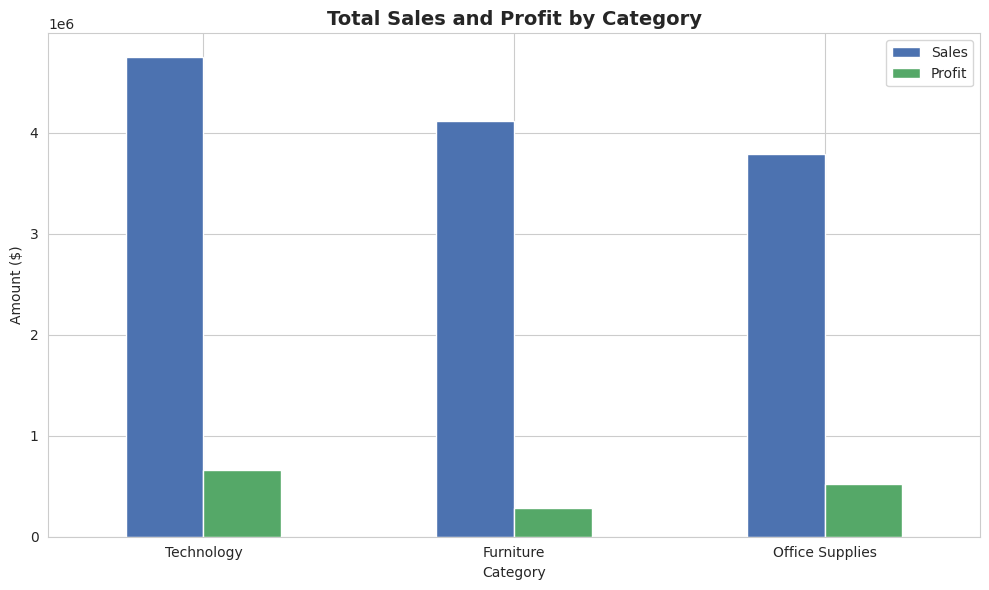

In [ ]:
cat = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)

fig, ax = plt.subplots()
cat.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868"])
ax.set_title("Total Sales and Profit by Category")
ax.set_ylabel("Amount ($)")
ax.set_xlabel("Category")
plt.xticks(rotation=0)
plt.tight_layout()
save_chart(fig, "sales_profit_by_category")
plt.show()

### 7.2 Sales by Region

Saved: charts/chart_02_sales_by_region.png


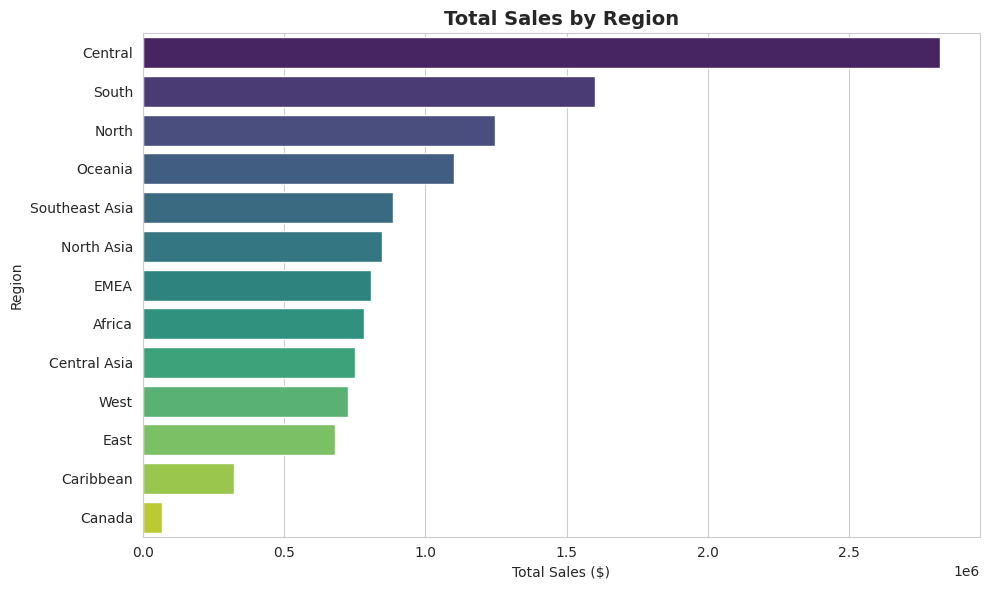

In [ ]:
region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
sns.barplot(x=region.values, y=region.index, ax=ax, palette="viridis", hue=region.index, legend=False)
ax.set_title("Total Sales by Region")
ax.set_xlabel("Total Sales ($)")
ax.set_ylabel("Region")
plt.tight_layout()
save_chart(fig, "sales_by_region")
plt.show()

### 7.3 Sales and Profit by Segment

Saved: charts/chart_03_sales_profit_by_segment.png


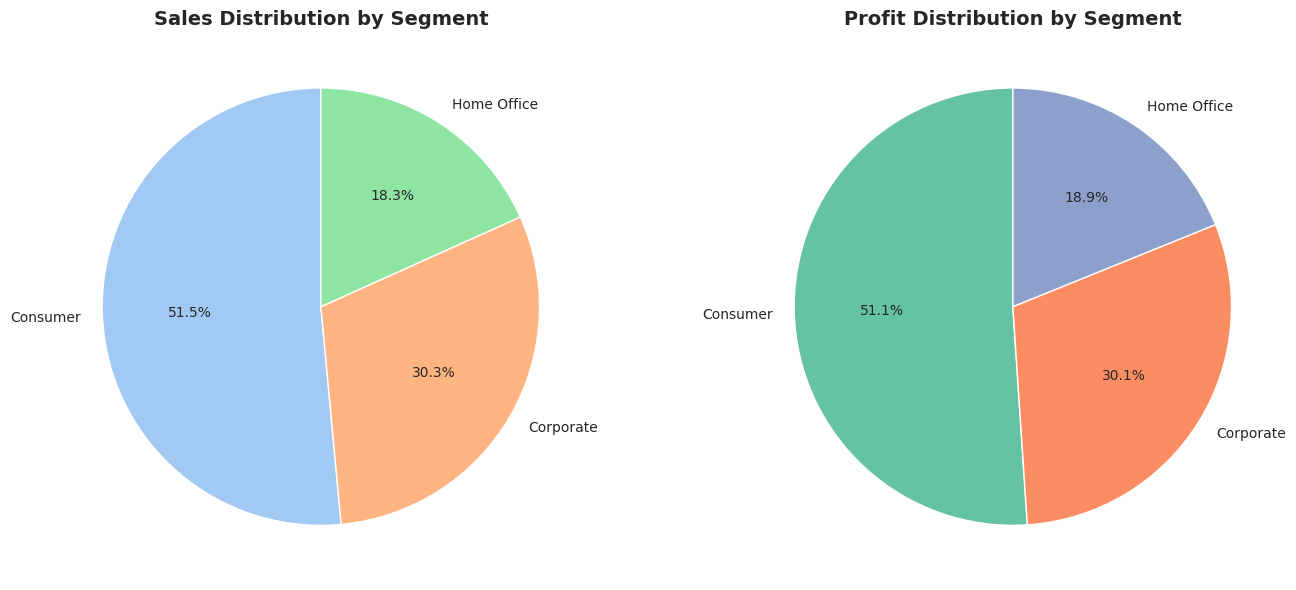

In [ ]:
seg = df.groupby("Segment")[["Sales", "Profit"]].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(seg["Sales"], labels=seg.index, autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("pastel"))
axes[0].set_title("Sales Distribution by Segment")
axes[1].pie(seg["Profit"], labels=seg.index, autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("Set2"))
axes[1].set_title("Profit Distribution by Segment")
plt.tight_layout()
save_chart(fig, "sales_profit_by_segment")
plt.show()

### 7.4 Profit by Sub-Category

Saved: charts/chart_04_profit_by_subcategory.png


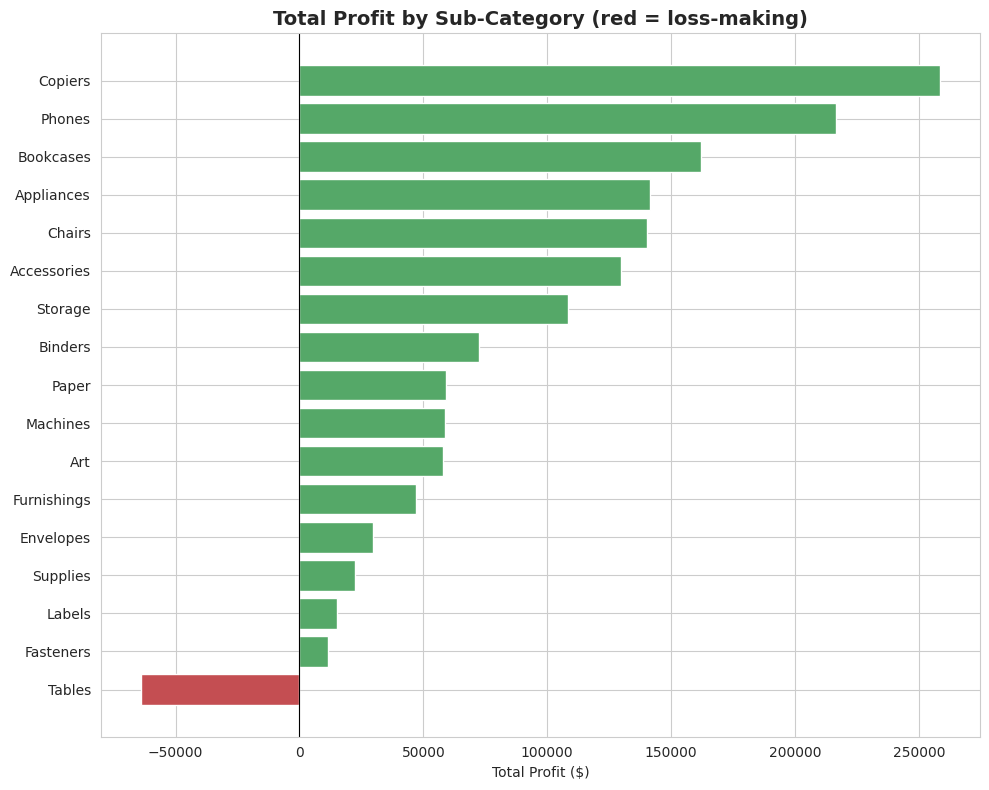

In [ ]:
sub = df.groupby("Sub-Category")["Profit"].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#C44E52" if v < 0 else "#55A868" for v in sub.values]
ax.barh(sub.index, sub.values, color=colors)
ax.set_title("Total Profit by Sub-Category (red = loss-making)")
ax.set_xlabel("Total Profit ($)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
save_chart(fig, "profit_by_subcategory")
plt.show()

### 7.5 Monthly Sales Trend Over Time

Saved: charts/chart_05_monthly_sales_trend.png


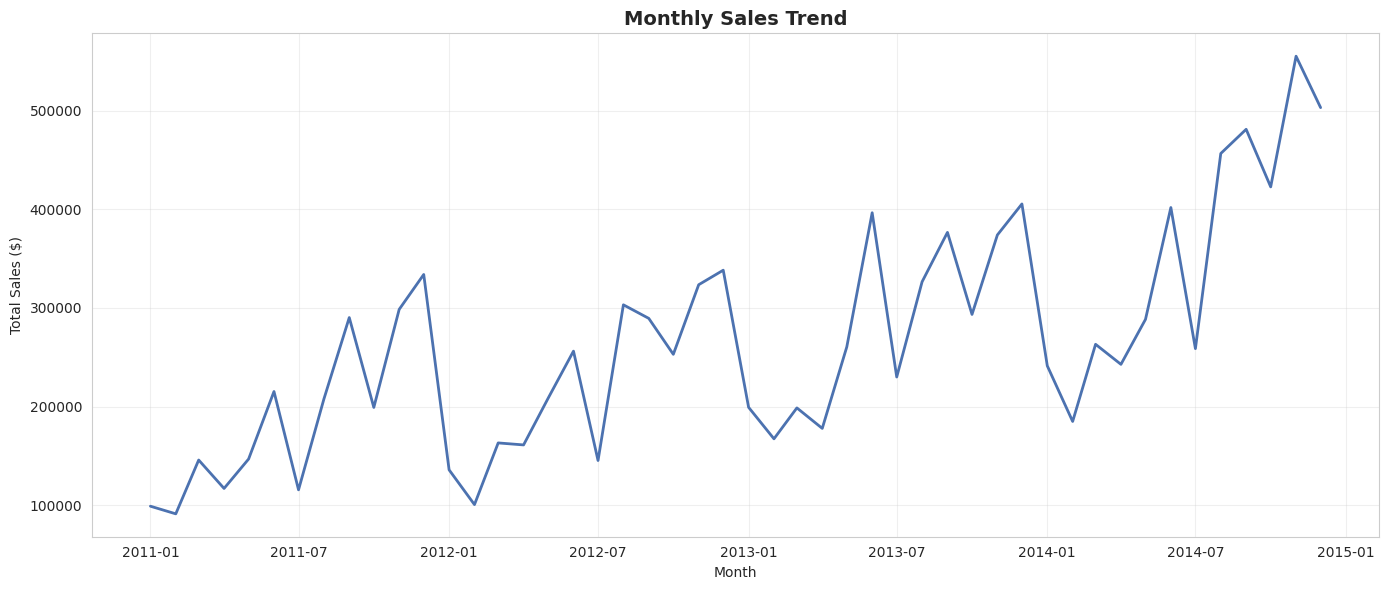

In [ ]:
monthly = df.groupby("Order Month")["Sales"].sum()
monthly.index = pd.to_datetime(monthly.index)
monthly = monthly.sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly.index, monthly.values, color="#4C72B0", linewidth=2)
ax.set_title("Monthly Sales Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_chart(fig, "monthly_sales_trend")
plt.show()

### 7.6 Top 5 Customers by Sales

Saved: charts/chart_06_top5_customers.png


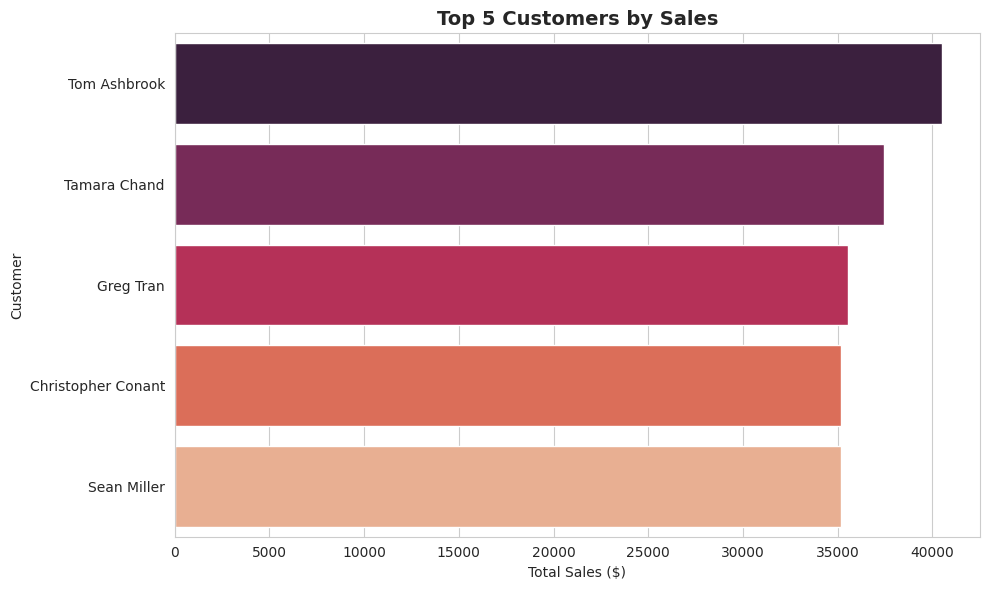

Top 5 Customers by Sales:
Customer Name
Tom Ashbrook          40488.07080
Tamara Chand          37457.33300
Greg Tran             35550.95428
Christopher Conant    35187.07640
Sean Miller           35170.93296
Name: Sales, dtype: float64


In [ ]:
top5 = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots()
sns.barplot(x=top5.values, y=top5.index, ax=ax, palette="rocket", hue=top5.index, legend=False)
ax.set_title("Top 5 Customers by Sales")
ax.set_xlabel("Total Sales ($)")
ax.set_ylabel("Customer")
plt.tight_layout()
save_chart(fig, "top5_customers")
plt.show()

print("Top 5 Customers by Sales:")
print(top5)

### 7.7 Discount vs. Profit Relationship

Saved: charts/chart_07_discount_vs_profit.png


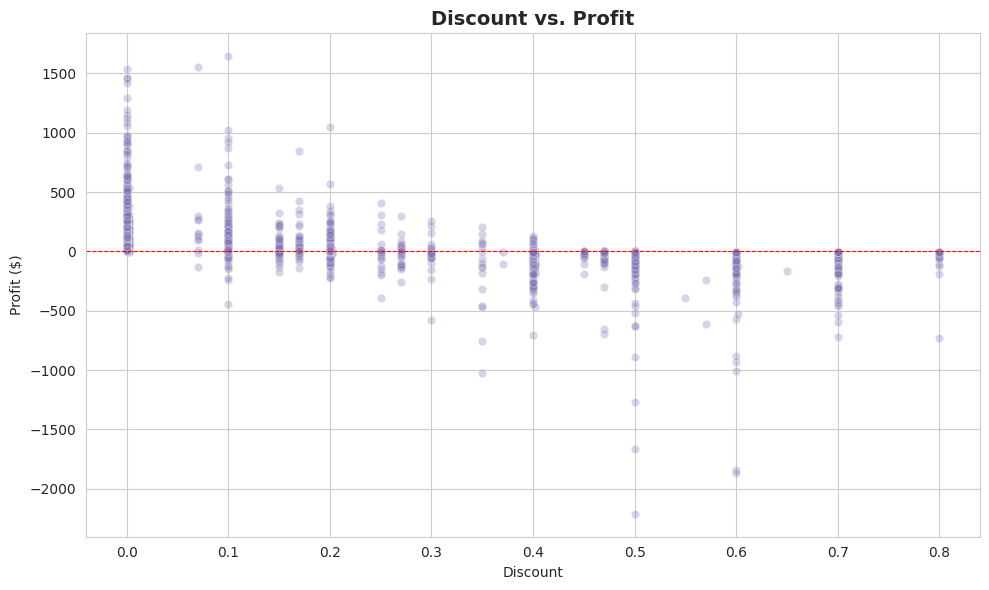

In [ ]:
sample = df.sample(min(5000, len(df)), random_state=42)  # sample for a readable scatter

fig, ax = plt.subplots()
sns.scatterplot(data=sample, x="Discount", y="Profit", alpha=0.3, ax=ax, color="#8172B3")
ax.set_title("Discount vs. Profit")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit ($)")
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
plt.tight_layout()
save_chart(fig, "discount_vs_profit")
plt.show()

### 7.8 Correlation Heatmap of Numeric Features

Saved: charts/chart_08_correlation_heatmap.png


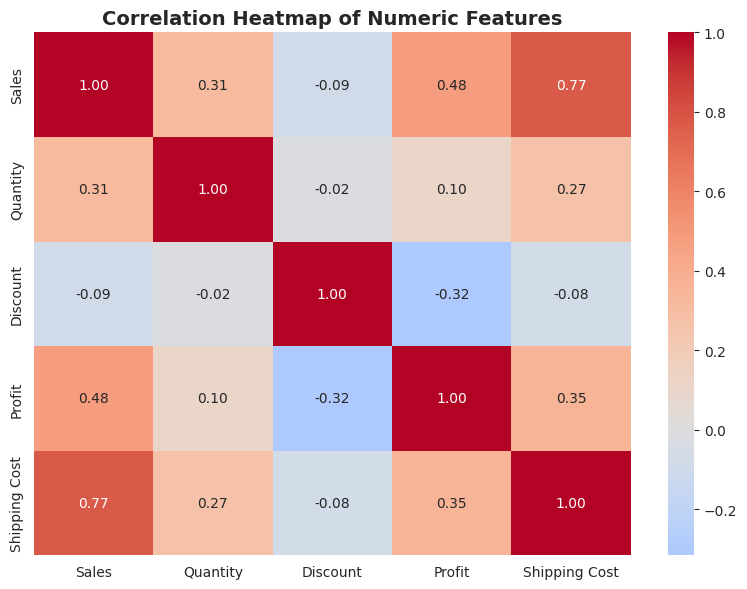

In [ ]:
num_cols = ["Sales", "Quantity", "Discount", "Profit", "Shipping Cost"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
save_chart(fig, "correlation_heatmap")
plt.show()

## 8. Key Performance Indicators (KPI) Summary

These are the headline KPIs that the Streamlit dashboard surfaces interactively.

In [ ]:
total_sales   = df["Sales"].sum()
total_profit  = df["Profit"].sum()
profit_margin = total_profit / total_sales * 100
total_orders  = df["Order ID"].nunique()

print("===== KEY PERFORMANCE INDICATORS =====")
print(f"Total Sales   : ${total_sales:,.0f}")
print(f"Total Profit  : ${total_profit:,.0f}")
print(f"Profit Margin : {profit_margin:.2f}%")
print(f"Total Orders  : {total_orders:,}")
print(f"Total Customers: {df['Customer Name'].nunique():,}")

===== KEY PERFORMANCE INDICATORS =====
Total Sales   : $12,642,502
Total Profit  : $1,467,457
Profit Margin : 11.61%
Total Orders  : 25,035
Total Customers: 795


## 9. Results and Findings

- **Technology** generates the highest sales and profit among the three categories, while
  **Furniture** has the thinnest margins.
- A handful of **sub-categories are loss-making** (notably *Tables*), highlighted in red in the
  profit-by-sub-category chart — clear targets for pricing or discount review.
- **Higher discounts are strongly associated with negative profit**, confirming that aggressive
  discounting erodes profitability.
- The **Consumer segment** drives the largest share of both sales and profit.
- Sales show a **clear upward trend** over the period, with seasonal peaks toward year-end.
- The **Top 5 customers** each contribute a disproportionately large share of total sales,
  underscoring the value of key-account retention.


## 10. Interactive Streamlit Dashboard

The interactive dashboard is provided as a separate **`app.py`** file (included in this package).
It loads the same dataset, applies the same cleaning, and provides:

- **Sidebar filters:** Region, Category, Sub-Category
- **KPI cards:** Total Sales, Total Profit, Profit Margin, Total Orders
- **Charts:** Sales by Category, Sales by Region, Top 5 Customers by Sales, Monthly Sales Trend

**To run the dashboard:**

```bash
streamlit run app.py
```

The relevant filtering logic is illustrated below (the same pattern `app.py` uses).

In [ ]:
def apply_filters(data, region="All", category="All", sub_category="All"):
    """Filter the dataframe the same way the Streamlit sidebar does."""
    out = data.copy()
    if region != "All":
        out = out[out["Region"] == region]
    if category != "All":
        out = out[out["Category"] == category]
    if sub_category != "All":
        out = out[out["Sub-Category"] == sub_category]
    return out

# Example: KPIs for the West region, Technology category
demo = apply_filters(df, region="West", category="Technology")
print("Filtered (West / Technology):")
print(f"  Rows         : {len(demo):,}")
print(f"  Total Sales  : ${demo['Sales'].sum():,.0f}")
print(f"  Total Profit : ${demo['Profit'].sum():,.0f}")

Filtered (West / Technology):
  Rows         : 599
  Total Sales  : $251,992
  Total Profit : $44,304


## 11. Conclusion

This project delivered a complete Business Intelligence workflow on the Global Superstore dataset:
the data was cleaned and preprocessed, explored through eight visualizations, and distilled into
clear KPIs. The accompanying Streamlit dashboard turns these insights into an interactive tool
where business users can filter by Region, Category, and Sub-Category and instantly see Total Sales,
Profit, and Top 5 Customers.

The analysis highlights actionable findings — the profitability drag from heavy discounting and
loss-making sub-categories — that a business could act on directly. The project reinforced skills in
**BI dashboarding, data storytelling, Streamlit interactivity, and visual KPI analysis**.


## 12. References

1. Global Superstore Dataset — Tableau sample sales dataset (widely used for BI practice).
2. Pandas Documentation — https://pandas.pydata.org/docs/
3. Matplotlib Documentation — https://matplotlib.org/stable/contents.html
4. Seaborn Documentation — https://seaborn.pydata.org/
5. Streamlit Documentation — https://docs.streamlit.io/
